RQ6 – Payment methods and order value by region

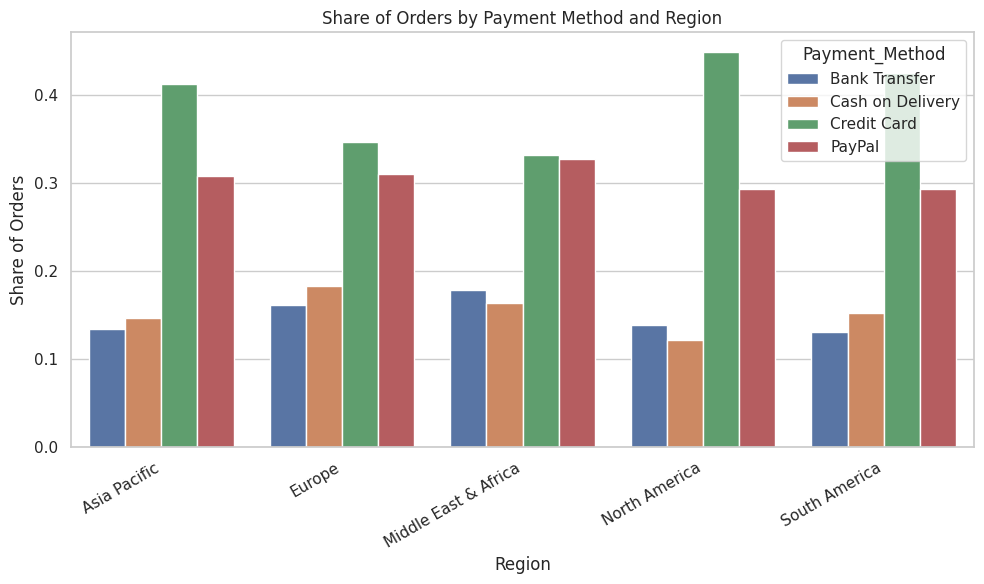

In [14]:
# RQ6: Payment methods and order value by region

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq6_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 1. Order counts by Region and Payment_Method
# -------------------
counts = (
    df.groupby(['Region', 'Payment_Method'], as_index=False)
      .agg(Order_Count=('Order_ID', 'nunique'))
)

# Total orders per region
total_region = (
    counts.groupby('Region', as_index=False)
          .agg(Total_Orders=('Order_Count', 'sum'))
)

counts = counts.merge(total_region, on='Region', how='left')
counts['Share_of_Orders'] = counts['Order_Count'] / counts['Total_Orders']

# -------------------
# 2. Average order value by Region and Payment_Method
# -------------------
aov = (
    df.groupby(['Region', 'Payment_Method'], as_index=False)
      .agg(Avg_Order_Value=('Total_Sales', 'mean'))
)

summary = counts.merge(aov, on=['Region', 'Payment_Method'], how='left')

summary.to_csv(OUTPUT_DIR / "RQ6_Table_PaymentMethod_Region_AOV.csv", index=False)

# -------------------
# 3. Plot share of orders (grouped bar)
# -------------------
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary,
    x='Region',
    y='Share_of_Orders',
    hue='Payment_Method'
)
plt.title("Share of Orders by Payment Method and Region")
plt.xlabel("Region")
plt.ylabel("Share of Orders")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ6_Figure1_PaymentMethod_Share_ByRegion.pdf", format="pdf")
plt.show()
plt.close()


### Interpretation of chart.

- Credit Card is the most widely used payment method, showing strong adoption across nearly all regions.

- PayPal also has a significant share, especially in Europe and North America, indicating high trust in digital wallets.

- Cash on Delivery is more common in Middle East & Africa and South America, reflecting regions where customers prefer receiving goods before paying.

- Bank Transfer has a smaller but noticeable share, particularly in Asia Pacific and Europe, suggesting its use for higher‑value or business‑related orders.

- Regional differences are clear—developed markets rely more on digital payments, while emerging markets show higher dependence on Cash on Delivery.

- Payment method diversity is highest in Asia Pacific and Europe, indicating mature e‑commerce ecosystems with multiple trusted payment options.

- North America shows a strong preference for Credit Card